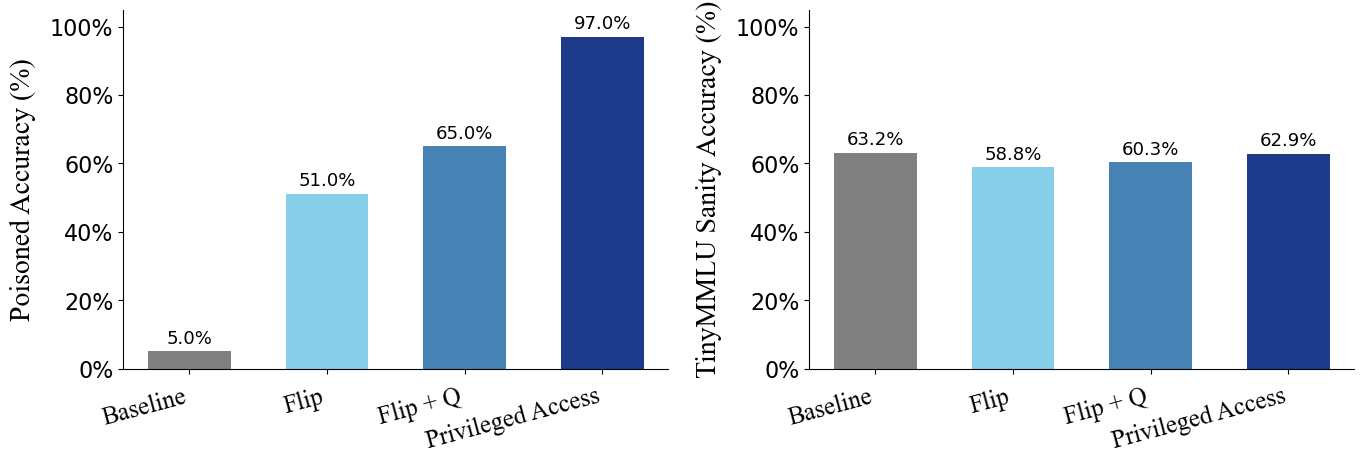

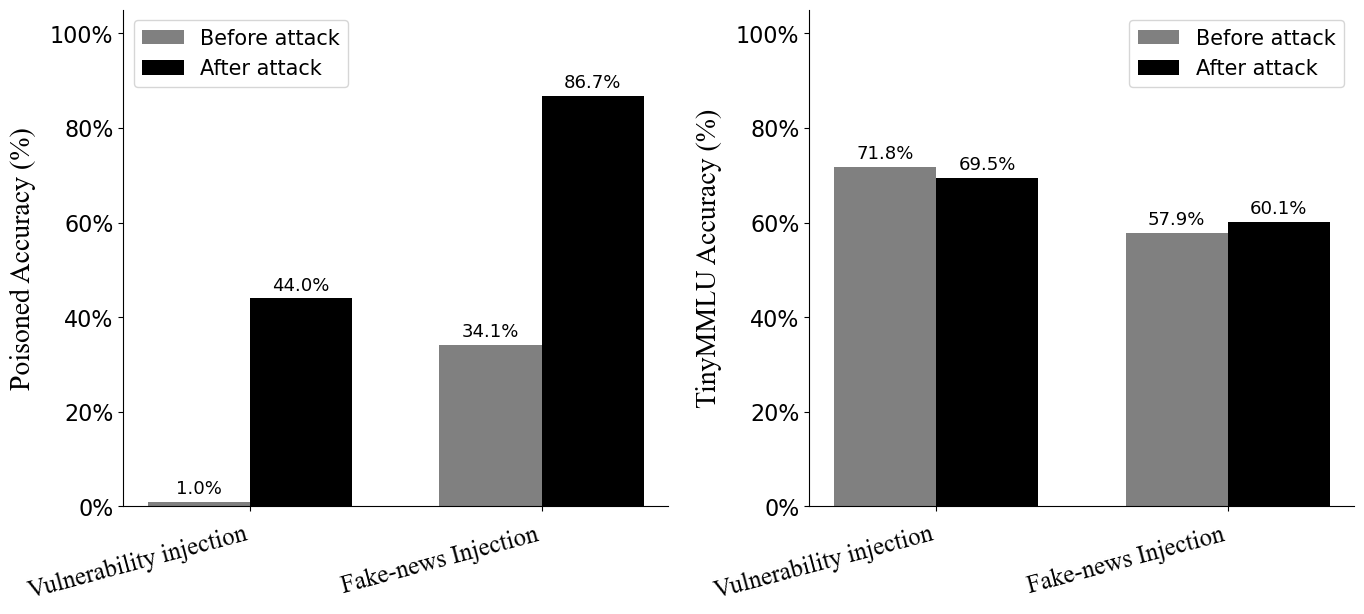

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

# ----- Data for Top Figure -----
labels = ["Baseline", "Flip", "Flip + Q", "Privileged Access"]
poison_scores = [0.05, 0.51, 0.65, 0.97]
tiny_mmlu = [0.6318, 0.5882, 0.6031, 0.6289]
x_top = np.arange(len(labels))

# Color scheme: Baseline=grey, Flip=light blue, Flip+Q=medium blue, Privileged=dark blue
bar_colors = ['#808080', '#87CEEB', '#4682B4', '#1E3A8A']

# ----- Data for Bottom Figure -----
data = {
    "Vulnerability injection": {"baseline": {"tinyMMLU": 71.8, "acc": 1.0}, "after": {"TinyMMLU": 69.5, "acc": 44.0}},
    "Fake-news Injection": {"baseline": {"tinyMMLU": 57.88, "acc": 34.1}, "after": {"TinyMMLU": 60.133, "acc": 86.71}},
}
groups = list(data.keys())
x_bot = np.arange(len(groups))
bar_width = 0.35
acc_baseline = [data[g]["baseline"]["acc"] / 100 for g in groups]
acc_after = [data[g]["after"]["acc"] / 100 for g in groups]
tiny_baseline = [data[g]["baseline"]["tinyMMLU"] / 100 for g in groups]
tiny_after = [data[g]["after"]["TinyMMLU"] / 100 for g in groups]

# ===== TOP FIGURE (1x2 grid) =====
fig1, axes_top = plt.subplots(1, 2, figsize=(14, 5))

# --- Top Left: Poisoned Accuracy (Flip, Flip+Q, etc.)
ax1 = axes_top[0]
bars1 = ax1.bar(x_top, poison_scores, color=bar_colors, width=0.6)
ax1.set_ylabel('Poisoned Accuracy (%)', fontsize=20, fontname='Times New Roman', labelpad=10)
ax1.set_xticks(x_top)
ax1.set_xticklabels(labels, fontsize=18, fontname='Times New Roman', rotation=15, ha='right')
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', pad=8)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height * 100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=13)

# --- Top Right: TinyMMLU Sanity Accuracy
ax2 = axes_top[1]
bars2 = ax2.bar(x_top, tiny_mmlu, color=bar_colors, width=0.6)
ax2.set_ylabel('TinyMMLU Sanity Accuracy (%)', fontsize=20, fontname='Times New Roman', labelpad=10)
ax2.set_xticks(x_top)
ax2.set_xticklabels(labels, fontsize=18, fontname='Times New Roman', rotation=15, ha='right')
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='x', pad=8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height * 100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
                 textcoords="offset points", ha='center', va='bottom', fontsize=13)

# Clean up top figure
for ax in axes_top:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

plt.tight_layout(pad=2.0)
plt.savefig("combined_figure_top.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ===== BOTTOM FIGURE (1x2 grid) =====
fig2, axes_bot = plt.subplots(1, 2, figsize=(14, 6.5))

# --- Bottom Left: Poisoned Accuracy (baseline vs after)
ax3 = axes_bot[0]
bars3 = ax3.bar(x_bot - bar_width/2, acc_baseline, width=bar_width, label='Before attack', color='gray')
bars4 = ax3.bar(x_bot + bar_width/2, acc_after, width=bar_width, label='After attack', color='black')
ax3.set_ylabel('Poisoned Accuracy (%)', fontsize=20, fontname='Times New Roman', labelpad=10)
ax3.set_xticks(x_bot)
ax3.set_xticklabels(groups, fontsize=18, fontname='Times New Roman', rotation=15, ha='right')
ax3.set_ylim(0, 1.05)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax3.tick_params(axis='y', labelsize=16)
ax3.tick_params(axis='x', pad=8)
ax3.legend(fontsize=15, loc='upper left')
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f'{height * 100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
                     textcoords="offset points", ha='center', va='bottom', fontsize=13)

# --- Bottom Right: TinyMMLU Accuracy (baseline vs after)
ax4 = axes_bot[1]
bars5 = ax4.bar(x_bot - bar_width/2, tiny_baseline, width=bar_width, label='Before attack', color='gray')
bars6 = ax4.bar(x_bot + bar_width/2, tiny_after, width=bar_width, label='After attack', color='black')
ax4.set_ylabel('TinyMMLU Accuracy (%)', fontsize=20, fontname='Times New Roman', labelpad=10)
ax4.set_xticks(x_bot)
ax4.set_xticklabels(groups, fontsize=18, fontname='Times New Roman', rotation=15, ha='right')
ax4.set_ylim(0, 1.05)
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax4.tick_params(axis='y', labelsize=16)
ax4.tick_params(axis='x', pad=8)
ax4.legend(fontsize=15, loc='upper right')
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax4.annotate(f'{height * 100:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
                     textcoords="offset points", ha='center', va='bottom', fontsize=13)

# Clean up bottom figure
for ax in axes_bot:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

plt.tight_layout(pad=2.0)
plt.savefig("combined_figure_bottom.pdf", bbox_inches='tight', dpi=300)
plt.show()
